Validation plots

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb



In [2]:
wandb.login()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: mitalee-garg (mitalee-garg-tu-darmstadt). Use `wandb login --relogin` to force relogin


True

Plots for validation set (800 epochs)

In [3]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/tud_presence_prediction/training_results/Transformer_V2_regressive/lightning_logs/version_3/metrics.csv"
metrics_df = pd.read_csv(file_path)
wandb.init(project="Parcel Delivery", name="graph_logging_run_100_epochs")

# Print available columns to check the correct column name
print("Available columns:", metrics_df.columns)

Available columns: Index(['train_precision_step', 'train_optimal_threshold_step', 'epoch',
       'train_recall_step', 'train_best_f1_step', 'train_auc_pr_step',
       'train_loss_step', 'train_accuracy_step', 'lr-AdamW', 'step',
       ...
       'train_precision/user_9', 'train_precision/user_6',
       'train_recall_epoch', 'train_loss/user_8', 'train_best_f1/user_2',
       'train_loss/user_0', 'train_recall/user_6', 'train_best_f1/user_11',
       'train_precision/user_2', 'train_precision/user_10'],
      dtype='object', length=129)


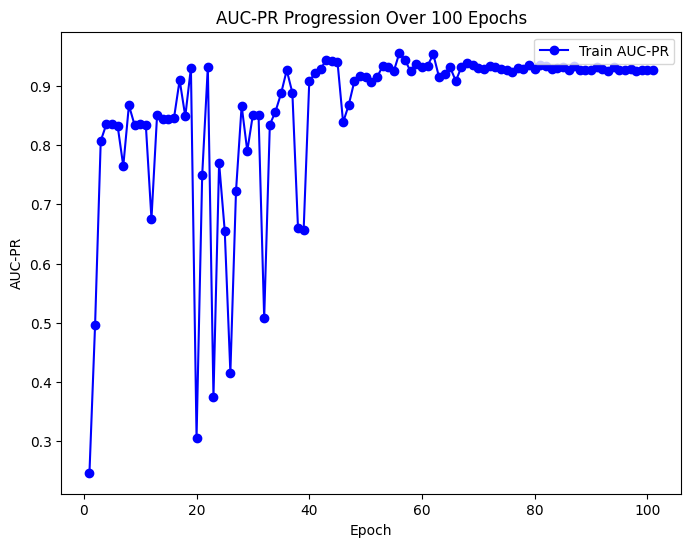

In [4]:
# Extract val_auc_pr' column, dropping any NaN values
val_auc_pr = metrics_df['val_auc_pr'].dropna().values
epochs = range(1, len(val_auc_pr) + 1)

# Plot AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, val_auc_pr, marker='o', linestyle='-', color='b', label='Train AUC-PR')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 100 Epochs')
plt.legend()
wandb.log({" AUC-PR Progression Over 100 Epochs": wandb.Image(plt)})

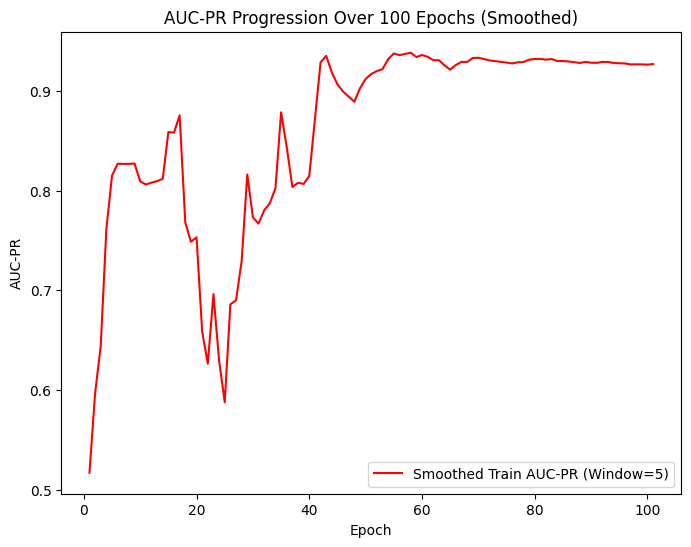

In [5]:
# Smoothing function (simple moving average)
def smooth(values, window_size):
    smoothed_values = pd.Series(values).rolling(window=window_size, min_periods=1, center=True).mean()
    return smoothed_values

# Apply smoothing with a window size of 5 (adjust as needed)
smoothed_auc_pr = smooth(val_auc_pr, window_size=5)

# Plot original and smoothed AUC-PR over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, smoothed_auc_pr, color='r', label='Smoothed Train AUC-PR (Window=5)')
plt.xlabel('Epoch')
plt.ylabel('AUC-PR')
plt.title('AUC-PR Progression Over 100 Epochs (Smoothed)')
plt.legend()
wandb.log({" AUC-PR Progression Over 100 Epochs (Smoothed)": wandb.Image(plt)})

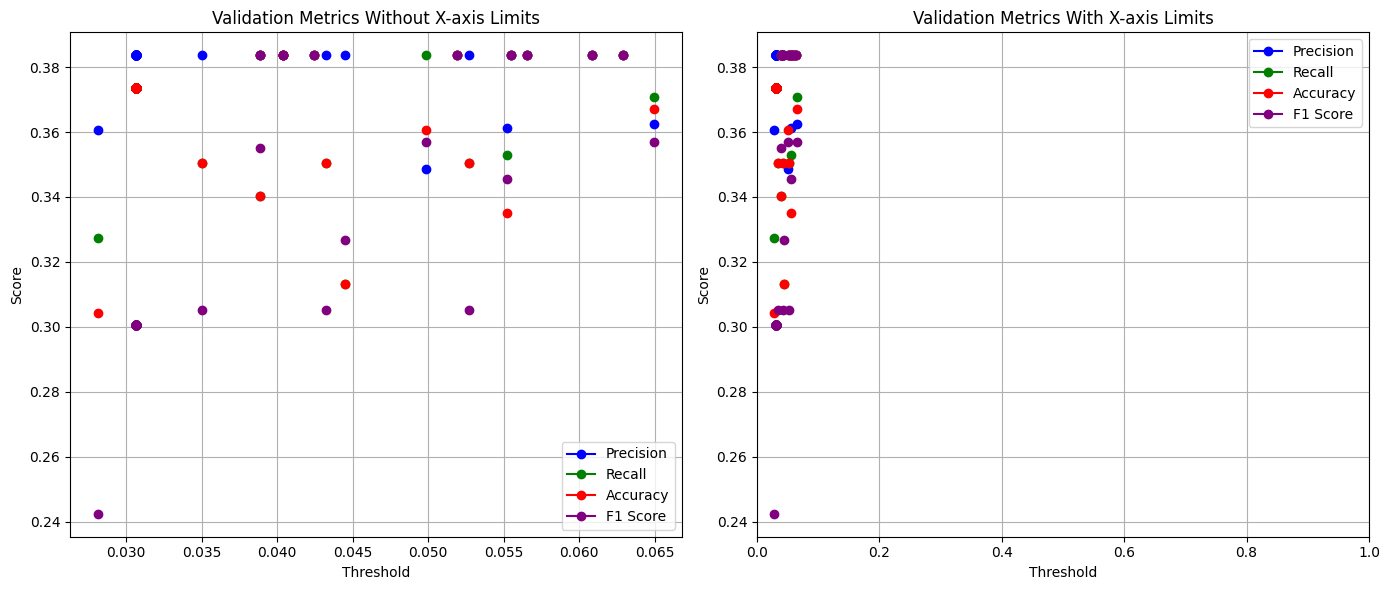

In [6]:
# Plot all four metrics together with markers for visibility
## Create Subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# Plot 1: Without x-axis limits
axs[0].plot(metrics_df['val_optimal_threshold'], metrics_df['val_precision'], label='Precision', color='blue', marker='o')
axs[0].plot(metrics_df['val_optimal_threshold'], metrics_df['val_recall'], label='Recall', color='green', marker='o')
axs[0].plot(metrics_df['val_optimal_threshold'], metrics_df['val_accuracy'], label='Accuracy', color='red', marker='o')
axs[0].plot(metrics_df['val_optimal_threshold'], metrics_df['val_best_f1'], label='F1 Score', color='purple', marker='o')
axs[0].set_title('Validation Metrics Without X-axis Limits')
axs[0].set_xlabel('Threshold')
axs[0].set_ylabel('Score')
axs[0].legend(loc='best')
axs[0].grid(True)

# Plot 2: With x-axis limits
axs[1].plot(metrics_df['val_optimal_threshold'], metrics_df['val_precision'], label='Precision', color='blue', marker='o')
axs[1].plot(metrics_df['val_optimal_threshold'], metrics_df['val_recall'], label='Recall', color='green', marker='o')
axs[1].plot(metrics_df['val_optimal_threshold'], metrics_df['val_accuracy'], label='Accuracy', color='red', marker='o')
axs[1].plot(metrics_df['val_optimal_threshold'], metrics_df['val_best_f1'], label='F1 Score', color='purple', marker='o')
axs[1].set_title('Validation Metrics With X-axis Limits')
axs[1].set_xlabel('Threshold')
axs[1].set_ylabel('Score')
axs[1].set_xlim(0, 1)  # Limit x-axis to 0 to 1
axs[1].legend(loc='best')
axs[1].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Log the figure to WandB
wandb.log({"Validation Metrics Subplots": wandb.Image(fig)})

# Show the plots
plt.show()

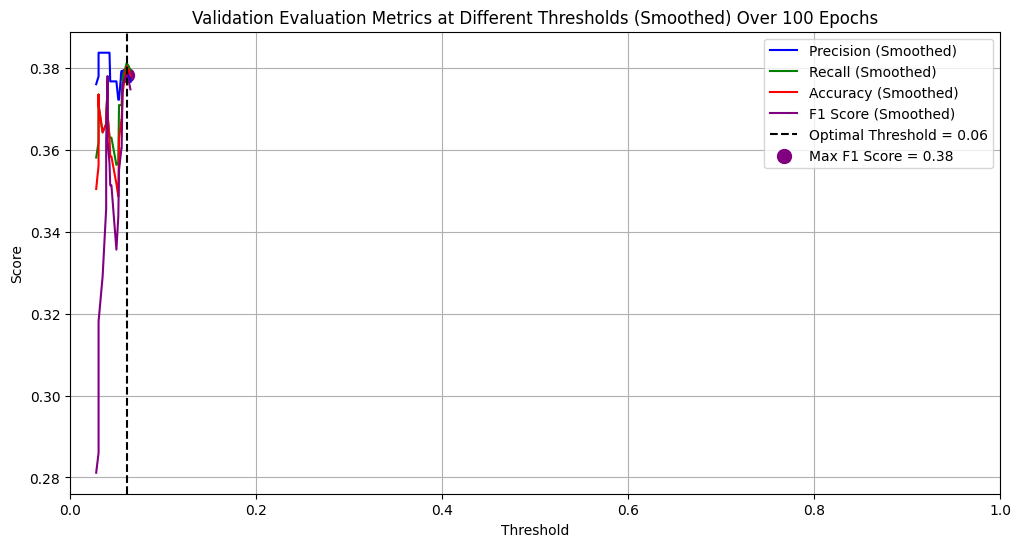

In [7]:
# Sort the data by 'optimal_threshold' to ensure continuous line plots
metrics_df = metrics_df.sort_values(by='val_optimal_threshold')

# Define a smoothing function using a moving average
def smooth(values, window_size):
    return pd.Series(values).rolling(window=window_size, min_periods=1, center=True).mean()

# Apply smoothing with a window size of 5 (adjust as needed)
thresholds = metrics_df['val_optimal_threshold']
precision_smooth = smooth(metrics_df['val_precision'], window_size=5)
recall_smooth = smooth(metrics_df['val_recall'], window_size=5)
accuracy_smooth = smooth(metrics_df['val_accuracy'], window_size=5)
f1_smooth = smooth(metrics_df['val_best_f1'], window_size=5)

# Find the maximum F1 score and corresponding threshold
max_f1_index = f1_smooth.idxmax()
optimal_threshold = thresholds[max_f1_index]
max_f1_score = f1_smooth[max_f1_index]

# Plot all four smoothed metrics together
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precision_smooth, label='Precision (Smoothed)', color='blue')
plt.plot(thresholds, recall_smooth, label='Recall (Smoothed)', color='green')
plt.plot(thresholds, accuracy_smooth, label='Accuracy (Smoothed)', color='red')
plt.plot(thresholds, f1_smooth, label='F1 Score (Smoothed)', color='purple')

# Highlight the optimal threshold on the plot
plt.axvline(x=optimal_threshold, color='black', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.scatter(optimal_threshold, max_f1_score, color='purple', s=100, label=f'Max F1 Score = {max_f1_score:.2f}')

# Customizing the plot with labels and grid
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Validation Evaluation Metrics at Different Thresholds (Smoothed) Over 100 Epochs')
plt.legend(loc='best')
plt.grid(True)
plt.xlim(0, 1)
# plt.xlim(thresholds.min() - 0.01, thresholds.max() + 0.01)

wandb.log({" Validation Evaluation Metrics at Different Thresholds (Smoothed) Over 100 Epochs": wandb.Image(plt)})
# Show the plot
plt.show()
wandb.finish()